# Data Visualization -- Module 2, Class 3

In this notebook you will create 5 types of visualizations from the Superstore dataset:

1. Histogram (distribution of Sales)
2. Boxplot (Profit distribution and outliers)
3. Bar chart (Sales by Category)
4. Correlation heatmap
5. Time series (monthly sales trend)

All 5 are pre-built. At the end, you create 2 additional plots on your own.

## **Task 1: Distribution Plots**


### Step 1: Load your cleaned data and import libraries:

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AIML/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])


### Step 2: Create the Sales histogram:

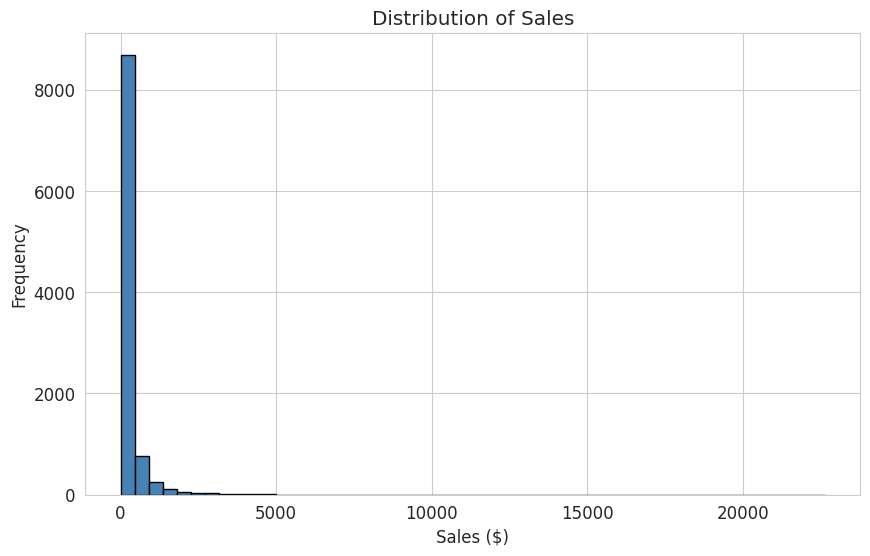

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

### Step 3: Create the Profit boxplot:


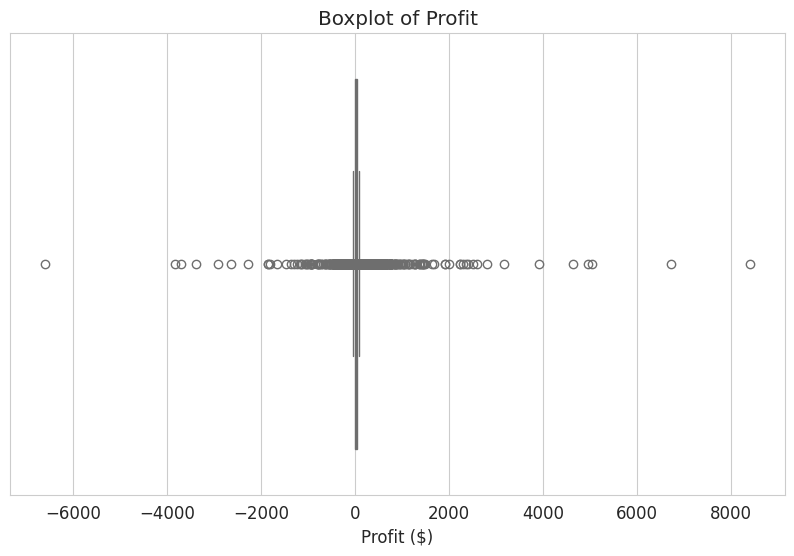

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')
plt.show()


### Step 4 : In a text cell below each plot, write 2-3 sentences: Is the Sales distribution normal,skewed, or bimodal?

**The Sales distribution is highly right-skewed (positively skewed). Most values are concentrated near small sales amounts, while a long tail extends toward very large sales values. This indicates that only a few transactions have extremely high sales**.

**In the Profit boxplot, the quartiles (Q1–Q3) are tightly clustered around zero, showing that most profits are relatively small. The median is also close to zero, suggesting many transactions have low profit or slight loss. There are many visible outliers on both sides, especially extreme negative and positive profit values.**


## **Task 2: Category-Wise Trends**

### Step 1: Calculate totals by category:

In [7]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

### Step 2: Plot the bar chart:

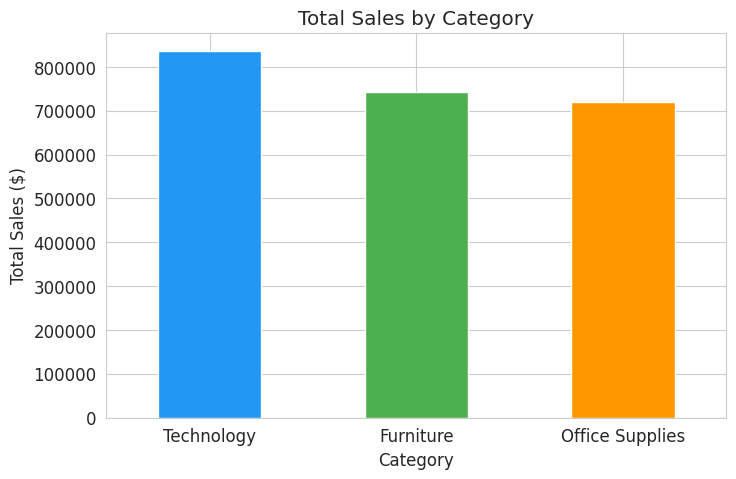

In [8]:
plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

### Step 3: Repeat for Region:

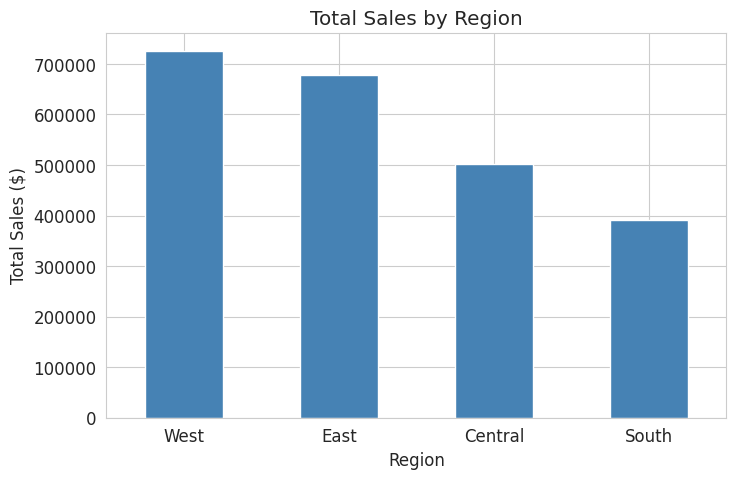

In [9]:

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

### Step 4: Write a text cell answering: Which category and region generate the most revenue? Any surprises?


 **The most revenue was generated by Technology Category.**
 **According to Region, West was the most dominant sales region.**

## **Task 3: Outlier Identification**

### Step 1: Calculate Q1, Q3, and IQR

In [10]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")

Q1: 1.73, Q3: 29.36, IQR: 27.64


### Step 2: Determine outlier boundaries:

In [11]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

Lower bound: -39.72, Upper bound: 70.82


### Step 3: Count outliers:

In [16]:
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]

print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*100:.2f}%)")

Number of outliers: 1881 out of 9994 rows (18.82%)


## **Task 4: Correlation Heatmap**

### Step 1: Select numerical columns and compute correlations:

In [18]:
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numerical_cols.corr()
print(corr_matrix)

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


### Step 2: Plot the heatmap:

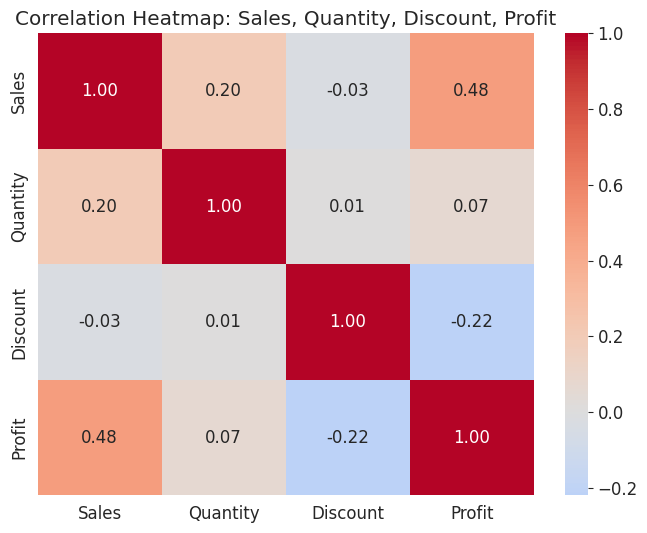

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.show()


### Step 3: Write a text cell: Which pairs have the strongest positive correlation? Is any relationship negative? What does the Discount-Profit correlation suggest?


**The strongest positive correlation is between Sales and Profit (0.48), indicating that higher sales generally lead to higher profit. There is a negative relationship between Discount and Profit (-0.22), meaning that increasing discounts tends to reduce profit. The Discount–Profit correlation suggests that offering higher discounts may hurt profitability, likely due to reduced margins.**

## **Task 5: Time-Based Trend**

### Step 1: Resample data to monthly totals:

In [20]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

/tmp/ipykernel_1166/1865667486.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


### Step 2: Plot the line chart:

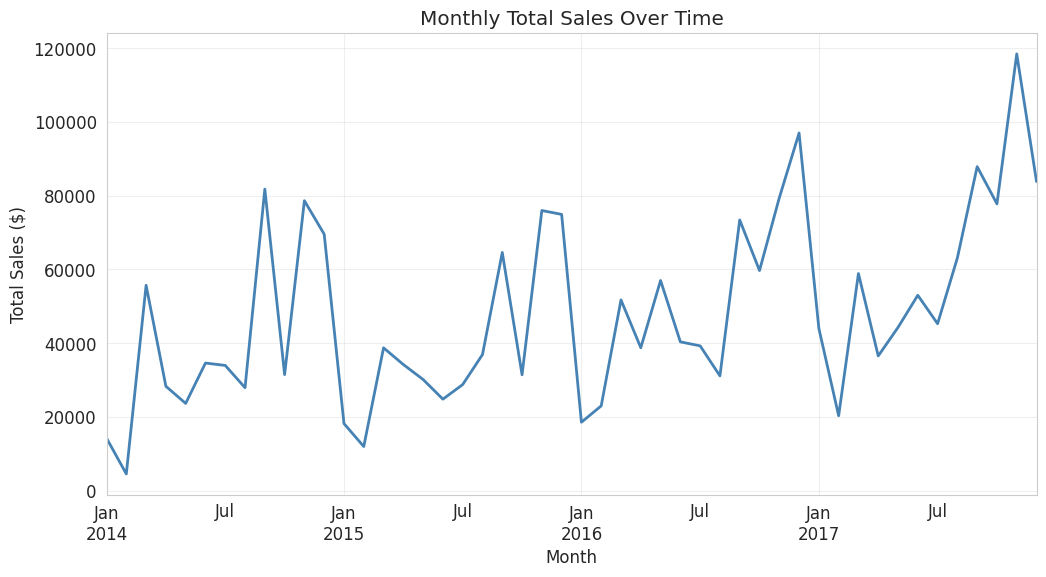

In [21]:
plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()


### Step 3: Write a text cell: Are there seasonal patterns? Spikes at end of year (holidayshopping)? Any notable dips?

**Strong mid-year (July) seasonality is the most reliable pattern. Year-end holiday spikes are not consistent. The business might benefit from focusing marketing and inventory planning around July, while preparing for predictable dips in January and August.**